# Setup B -- Effective Sample Size for Spoon-Based NIR Measurement

Independent spoon samples measured as repeated static optical measurements during one spectral acquisition

## Background

Setup B represents a spoon or flip-sampler interface where powder originates from a flowing process stream, is captured in a spoon, and is measured by the NIR probe while static during each spoon presentation.

The upstream process is dynamic, but each optical event is treated as a static-bed measurement during the spoon exposure. During one reported spectrum, multiple spoon presentations may occur. Under the assumptions used here, effective sample size is governed by optical interaction mass per spoon, total acquisition time, and spoon flipping frequency. It is not directly governed by upstream throughput in this first deterministic model.

## Objective

This notebook simulates Setup B effective sample size by quantifying:

- static optical sampled mass per spoon
- number of spoon samples contributing during one spectrum
- effective sampled mass per spectrum

as functions of penetration depth, bulk density, flip frequency, and acquisition settings.

## Theory

For one spoon presentation (static measurement):

$$A_{probe} = \\pi\\left(\\frac{D_{probe}}{2}\\right)^2$$

$$V_{static} \\approx A_{probe}\\,d_{pen}$$

$$m_{static} = \\rho_{bulk}\\,V_{static}$$

Acquisition timing:

$$t_{acq} = N_{subscans}\\,t_{int}$$

$$t_{spoon} = \\frac{1}{f_{flip}}$$

$$N_{spoons} = t_{acq}\\,f_{flip}$$

Effective sampled mass during one reported spectrum:

$$m_{eff} = m_{static}\\,N_{spoons}$$

Symbol definitions and units:

- $D_{probe}$: probe diameter [m]
- $A_{probe}$: probe area [m$^2$]
- $d_{pen}$: effective penetration depth [m]
- $\\rho_{bulk}$: bulk density [kg/m$^3$]
- $V_{static}$: static sampled volume per spoon [m$^3$]
- $m_{static}$: static sampled mass per spoon [kg]
- $N_{subscans}$: number of averaged sub-scans [-]
- $t_{int}$: integration time per sub-scan [s]
- $t_{acq}$: total acquisition time [s]
- $f_{flip}$: spoon flipping frequency [Hz]
- $t_{spoon}$: spoon interval [s]
- $N_{spoons}$: spoon samples contributing during one acquisition [-]
- $m_{eff}$: effective sampled mass per spectrum [kg]

## Interpretation of the Model

In this setup, one spoon presentation is one independent static optical sample. If acquisition time spans multiple spoon presentations, the reported spectrum integrates multiple independent increments.

In this notebook, $N_{spoons}$ is allowed to be non-integer as a deterministic first approximation for effective mass scaling. Under the stated assumptions, throughput is not explicitly modeled.

## Assumptions

- spoon always completely filled
- filling is reproducible
- consecutive spoons are independent
- powder is static during each spoon measurement
- circular probe window
- cylindrical optical interaction volume approximation
- uniform bulk density
- no resampling within a spoon
- no segregation correction
- no stochastic independence correction
- no detailed radiative transfer model yet

## Input Parameters

Baseline optical, acquisition, and spoon-frequency settings are defined below. SI units are used internally, while engineering units are kept in labels and summary tables for readability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Baseline optical parameter
probe_diameter_mm = 5.0

# Penetration depth range (inclusive)
penetration_depths_mm = np.arange(0.1, 2.0 + 0.1, 0.1)

# Bulk density scenarios (representative spoon-bed states)
bulk_densities_g_cm3 = np.array([0.4, 0.5, 0.6])

# Acquisition settings
n_subscans = 256
integration_time_ms = 15.0

# Spoon interval scenarios (seconds between spoon flips)
spoon_intervals_s = np.array([1, 2, 3, 4, 5], dtype=float)

acquisition_time_ms = n_subscans * integration_time_ms
acquisition_time_s = acquisition_time_ms / 1000.0
total_spectral_acquisition_time_s = acquisition_time_s

# Optional derived frequency values (not used as primary parameterization)
flip_frequencies_hz = 1.0 / spoon_intervals_s

input_summary_df = pd.DataFrame(
    {
        "parameter": [
            "probe_diameter_mm",
            "penetration_depth_start_mm",
            "penetration_depth_end_mm",
            "penetration_depth_step_mm",
            "n_subscans",
            "integration_time_ms",
            "acquisition_time_ms",
            "acquisition_time_s",
            "bulk_densities_g_cm3",
            "spoon_intervals_s",
        ],
        "value": [
            probe_diameter_mm,
            float(penetration_depths_mm.min()),
            float(penetration_depths_mm.max()),
            0.1,
            n_subscans,
            integration_time_ms,
            acquisition_time_ms,
            acquisition_time_s,
            ", ".join([f"{v:.2f}" for v in bulk_densities_g_cm3]),
            ", ".join([f"{v:.0f}" for v in spoon_intervals_s]),
        ],
    }
)

flip_summary_df = pd.DataFrame(
    {
        "spoon_interval_s": spoon_intervals_s,
        "spoon_presentations": total_spectral_acquisition_time_s / spoon_intervals_s,
        "total_spectral_acquisition_time_s": total_spectral_acquisition_time_s,
    }
)

input_summary_df

,parameter,value
0,probe_diameter_mm,5.0
1,penetration_depth_start_mm,0.1
2,penetration_depth_end_mm,2.0
3,penetration_depth_step_mm,0.1
4,n_subscans,256
5,integration_time_ms,15.0
6,acquisition_time_ms,3840.0
7,acquisition_time_s,3.84
8,bulk_densities_g_cm3,"0.40, 0.50, 0.60"
9,spoon_intervals_s,"1, 2, 3, 4, 5"


In [3]:
flip_summary_df

,spoon_interval_s,spoon_presentations,total_spectral_acquisition_time_s
0,1.0,3.840,3.84
1,2.0,1.920,3.84
2,3.0,1.280,3.84
3,4.0,0.960,3.84
4,5.0,0.768,3.84


In [4]:
def mm_to_m(length_mm: float) -> float:
    """Convert millimeters to meters."""
    return length_mm / 1000.0


def ms_to_s(time_ms: float) -> float:
    """Convert milliseconds to seconds."""
    return time_ms / 1000.0


def g_cm3_to_kg_m3(density_g_cm3: float) -> float:
    """Convert density from g/cm^3 to kg/m^3."""
    return density_g_cm3 * 1000.0


def circular_probe_area_m2(probe_diameter_m: float) -> float:
    """Calculate circular probe area in square meters."""
    return np.pi * (probe_diameter_m / 2.0) ** 2


def static_sampled_volume_m3(probe_area_m2: float, penetration_depth_m: float) -> float:
    """Approximate static sampled volume per spoon using a cylinder model."""
    return probe_area_m2 * penetration_depth_m


def static_sampled_mass_kg(bulk_density_kg_m3: float, volume_m3: float) -> float:
    """Calculate static sampled mass per spoon."""
    return bulk_density_kg_m3 * volume_m3


def acquisition_time_s_from_settings(n_subscans_value: int, integration_time_s: float) -> float:
    """Calculate total acquisition time from sub-scan settings."""
    return n_subscans_value * integration_time_s


def spoons_contributing_from_interval(acquisition_time_s_value: float, spoon_interval_s_value: float) -> float:
    """Estimate spoon samples contributing during one acquisition window from spoon interval."""
    return acquisition_time_s_value / spoon_interval_s_value


def effective_sampled_mass_kg(static_mass_kg: float, n_spoons: float) -> float:
    """Calculate effective sampled mass per reported spectrum."""
    return static_mass_kg * n_spoons

In [5]:
rows = []

probe_diameter_m = mm_to_m(probe_diameter_mm)
probe_area_m2 = circular_probe_area_m2(probe_diameter_m)
probe_area_cm2 = probe_area_m2 * 1e4
integration_time_s = ms_to_s(integration_time_ms)
acq_time_s = acquisition_time_s_from_settings(n_subscans, integration_time_s)

total_spectral_acquisition_time_s = acq_time_s

for penetration_depth_mm in penetration_depths_mm:
    penetration_depth_m = mm_to_m(float(penetration_depth_mm))
    penetration_depth_cm = float(penetration_depth_mm) / 10.0
    volume_m3 = static_sampled_volume_m3(probe_area_m2, penetration_depth_m)
    volume_mm3 = volume_m3 * 1e9
    spoon_sample_volume_cm3 = probe_area_cm2 * penetration_depth_cm

    for bulk_density_g_cm3 in bulk_densities_g_cm3:
        bulk_density_kg_m3 = g_cm3_to_kg_m3(float(bulk_density_g_cm3))
        static_mass_kg = static_sampled_mass_kg(bulk_density_kg_m3, volume_m3)
        static_mass_g = static_mass_kg * 1000.0
        static_mass_mg = static_mass_g * 1000.0

        for spoon_interval_s in spoon_intervals_s:
            spoon_presentations = spoons_contributing_from_interval(acq_time_s, float(spoon_interval_s))
            eff_mass_kg = effective_sampled_mass_kg(static_mass_kg, spoon_presentations)
            eff_mass_g = eff_mass_kg * 1000.0
            eff_mass_mg = eff_mass_g * 1000.0

            rows.append(
                {
                    "setup": "B",
                    "penetration_depth_mm": float(penetration_depth_mm),
                    "penetration_depth_m": penetration_depth_m,
                    "penetration_depth_cm": penetration_depth_cm,
                    "bulk_density_g_cm3": float(bulk_density_g_cm3),
                    "bulk_density_g_per_cm3": float(bulk_density_g_cm3),
                    "bulk_density_kg_m3": bulk_density_kg_m3,
                    "probe_diameter_mm": probe_diameter_mm,
                    "probe_area_m2": probe_area_m2,
                    "illuminated_area_cm2": probe_area_cm2,
                    "static_sampled_volume_m3": volume_m3,
                    "static_sampled_volume_mm3": volume_mm3,
                    "spoon_sample_volume_cm3": spoon_sample_volume_cm3,
                    "static_sampled_mass_kg": static_mass_kg,
                    "static_sampled_mass_g": static_mass_g,
                    "static_sampled_mass_mg": static_mass_mg,
                    "n_subscans": n_subscans,
                    "integration_time_ms": integration_time_ms,
                    "acquisition_time_s": acq_time_s,
                    "total_spectral_acquisition_time_s": total_spectral_acquisition_time_s,
                    "spoon_interval_s": float(spoon_interval_s),
                    "flip_frequency_hz": 1.0 / float(spoon_interval_s),
                    "spoons_contributing": spoon_presentations,
                    "effective_sampled_mass_kg": eff_mass_kg,
                    "effective_sample_size_g": eff_mass_g,
                    "effective_sampled_mass_mg": eff_mass_mg,
                    "effective_sample_size_mg": eff_mass_mg,
                }
            )

results_df = pd.DataFrame(rows)
results_df.head()

,setup,penetration_depth_mm,penetration_depth_m,penetration_depth_cm,bulk_density_g_cm3,bulk_density_g_per_cm3,bulk_density_kg_m3,probe_diameter_mm,probe_area_m2,illuminated_area_cm2,...,integration_time_ms,acquisition_time_s,total_spectral_acquisition_time_s,spoon_interval_s,flip_frequency_hz,spoons_contributing,effective_sampled_mass_kg,effective_sample_size_g,effective_sampled_mass_mg,effective_sample_size_mg
0,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,1.0,1.000000,3.840,3.015929e-06,0.003016,3.015929,3.015929
1,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,2.0,0.500000,1.920,1.507964e-06,0.001508,1.507964,1.507964
2,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,3.0,0.333333,1.280,1.005310e-06,0.001005,1.005310,1.005310
3,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,4.0,0.250000,0.960,7.539822e-07,0.000754,0.753982,0.753982
4,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,5.0,0.200000,0.768,6.031858e-07,0.000603,0.603186,0.603186


## Interpretation of Simulation Table

Each row represents one parameter combination of penetration depth, bulk density, and time between spoon flips.

- `static_sampled_mass_mg` is the per-spoon static optical sampled mass.
- `spoons_contributing` is the deterministic estimate of spoon presentations during one spectrum.
- `effective_sampled_mass_mg` is the scaled effective sampled mass per spectrum under independent spoon assumptions.

In [6]:
results_display_df = results_df.copy()
results_display_df["penetration_depth_m"] = results_display_df["penetration_depth_m"].round(6)
results_display_df["probe_area_m2"] = results_display_df["probe_area_m2"].round(8)
results_display_df["static_sampled_volume_m3"] = results_display_df["static_sampled_volume_m3"].round(12)
results_display_df["static_sampled_volume_mm3"] = results_display_df["static_sampled_volume_mm3"].round(4)
results_display_df["spoon_sample_volume_cm3"] = results_display_df["spoon_sample_volume_cm3"].round(6)
results_display_df["static_sampled_mass_kg"] = results_display_df["static_sampled_mass_kg"].round(10)
results_display_df["static_sampled_mass_mg"] = results_display_df["static_sampled_mass_mg"].round(4)
results_display_df["acquisition_time_s"] = results_display_df["acquisition_time_s"].round(4)
results_display_df["spoon_interval_s"] = results_display_df["spoon_interval_s"].round(4)
results_display_df["spoons_contributing"] = results_display_df["spoons_contributing"].round(4)
results_display_df["effective_sampled_mass_kg"] = results_display_df["effective_sampled_mass_kg"].round(10)
results_display_df["effective_sampled_mass_mg"] = results_display_df["effective_sampled_mass_mg"].round(4)

grouped_summary_df = (
    results_df.groupby(["bulk_density_g_cm3", "spoon_interval_s"], as_index=False)
    .agg(
        static_mass_mg_min=("static_sampled_mass_mg", "min"),
        static_mass_mg_max=("static_sampled_mass_mg", "max"),
        effective_mass_mg_min=("effective_sampled_mass_mg", "min"),
        effective_mass_mg_max=("effective_sampled_mass_mg", "max"),
    )
)

results_display_df

,setup,penetration_depth_mm,penetration_depth_m,penetration_depth_cm,bulk_density_g_cm3,bulk_density_g_per_cm3,bulk_density_kg_m3,probe_diameter_mm,probe_area_m2,illuminated_area_cm2,...,integration_time_ms,acquisition_time_s,total_spectral_acquisition_time_s,spoon_interval_s,flip_frequency_hz,spoons_contributing,effective_sampled_mass_kg,effective_sample_size_g,effective_sampled_mass_mg,effective_sample_size_mg
0,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,1.0,1.000000,3.840,3.015900e-06,0.003016,3.0159,3.015929
1,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,2.0,0.500000,1.920,1.508000e-06,0.001508,1.5080,1.507964
2,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,3.0,0.333333,1.280,1.005300e-06,0.001005,1.0053,1.005310
3,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,4.0,0.250000,0.960,7.540000e-07,0.000754,0.7540,0.753982
4,B,0.1,0.0001,0.01,0.4,0.4,400.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,5.0,0.200000,0.768,6.032000e-07,0.000603,0.6032,0.603186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,B,2.0,0.0020,0.20,0.6,0.6,600.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,1.0,1.000000,3.840,9.047790e-05,0.090478,90.4779,90.477868
296,B,2.0,0.0020,0.20,0.6,0.6,600.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,2.0,0.500000,1.920,4.523890e-05,0.045239,45.2389,45.238934
297,B,2.0,0.0020,0.20,0.6,0.6,600.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,3.0,0.333333,1.280,3.015930e-05,0.030159,30.1593,30.159289
298,B,2.0,0.0020,0.20,0.6,0.6,600.0,5.0,0.00002,0.19635,...,15.0,3.84,3.84,4.0,0.250000,0.960,2.261950e-05,0.022619,22.6195,22.619467


In [7]:
grouped_summary_df.round(4)

,bulk_density_g_cm3,spoon_interval_s,static_mass_mg_min,static_mass_mg_max,effective_mass_mg_min,effective_mass_mg_max
0,0.4,1.0,0.7854,15.7080,3.0159,60.3186
1,0.4,2.0,0.7854,15.7080,1.5080,30.1593
2,0.4,3.0,0.7854,15.7080,1.0053,20.1062
3,0.4,4.0,0.7854,15.7080,0.7540,15.0796
4,0.4,5.0,0.7854,15.7080,0.6032,12.0637
5,0.5,1.0,0.9817,19.6350,3.7699,75.3982
6,0.5,2.0,0.9817,19.6350,1.8850,37.6991
7,0.5,3.0,0.9817,19.6350,1.2566,25.1327
8,0.5,4.0,0.9817,19.6350,0.9425,18.8496
9,0.5,5.0,0.9817,19.6350,0.7540,15.0796


## Plot 1: Static Sampled Volume per Spoon vs Penetration Depth

This plot shows static sampled volume per spoon as a function of penetration depth for the cylindrical first-generation optical approximation.

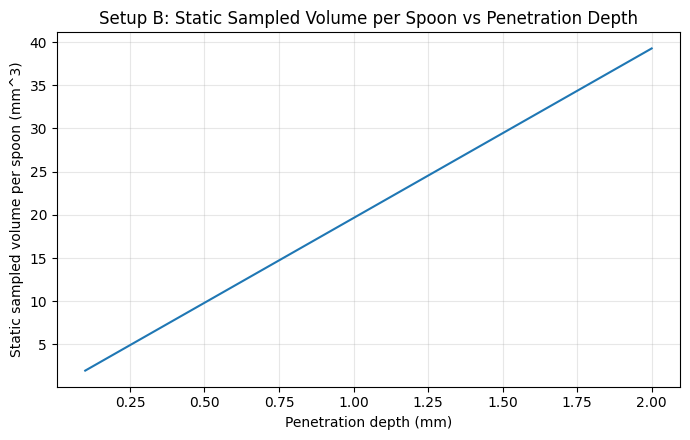

In [8]:
volume_vs_depth_df = (
    results_df[["penetration_depth_mm", "static_sampled_volume_mm3"]]
    .drop_duplicates()
    .sort_values("penetration_depth_mm")
)

fig_setup_b_volume, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(volume_vs_depth_df["penetration_depth_mm"], volume_vs_depth_df["static_sampled_volume_mm3"])
ax.set_xlabel("Penetration depth (mm)")
ax.set_ylabel("Static sampled volume per spoon (mm^3)")
ax.set_title("Setup B: Static Sampled Volume per Spoon vs Penetration Depth")
ax.grid(True, alpha=0.3)
fig_setup_b_volume.tight_layout()
plt.show()


## Plot 2: Static Sample Mass per Spoon (Representative Depth)

This plot shows static sample mass per spoon (mg) for bulk densities 0.4, 0.5, and 0.6 g/cm$^3$, using the Setup B spoon geometry at a representative penetration depth of 1.0 mm.

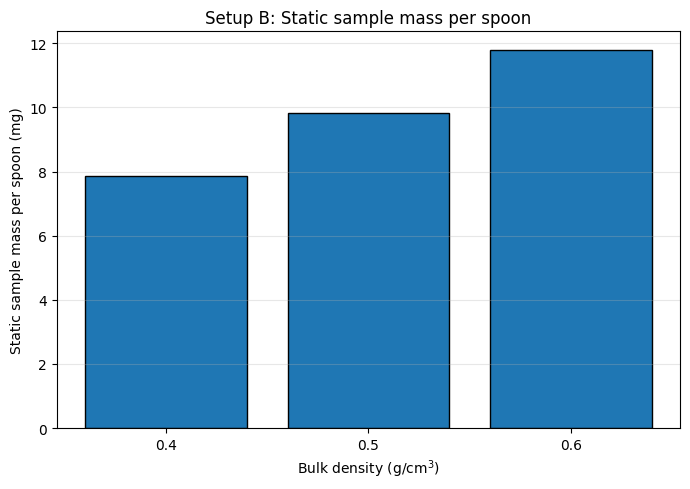

,bulk_density_g_per_cm3,static_sample_mass_g,static_sample_mass_mg,spoon_sample_volume_cm3,representative_penetration_depth_mm
0,0.4,0.007854,7.853982,0.019635,1.0
1,0.5,0.009817,9.817477,0.019635,1.0
2,0.6,0.011781,11.780972,0.019635,1.0


In [9]:
representative_penetration_depth_mm_plot2 = 1.0
representative_penetration_depth_cm_plot2 = representative_penetration_depth_mm_plot2 / 10.0
illuminated_area_cm2_plot2 = probe_area_m2 * 1e4
spoon_sample_volume_cm3_plot2 = illuminated_area_cm2_plot2 * representative_penetration_depth_cm_plot2

plot2_results = []
for rho in np.array([0.4, 0.5, 0.6]):
    static_sample_mass_g = rho * spoon_sample_volume_cm3_plot2
    plot2_results.append(
        {
            "bulk_density_g_per_cm3": rho,
            "static_sample_mass_g": static_sample_mass_g,
            "static_sample_mass_mg": static_sample_mass_g * 1000.0,
            "spoon_sample_volume_cm3": spoon_sample_volume_cm3_plot2,
            "representative_penetration_depth_mm": representative_penetration_depth_mm_plot2,
        }
    )

df_plot2 = pd.DataFrame(plot2_results)

fig_setup_b_static_sample_mass, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    df_plot2["bulk_density_g_per_cm3"].astype(str),
    df_plot2["static_sample_mass_mg"],
    edgecolor="black",
)
ax.set_xlabel("Bulk density (g/cm$^3$)")
ax.set_ylabel("Static sample mass per spoon (mg)")
ax.set_title("Setup B: Static sample mass per spoon")
ax.grid(axis="y", alpha=0.3)
fig_setup_b_static_sample_mass.tight_layout()
plt.show()

df_plot2


## Plot 3: Spoons Contributing per Spectrum vs Spoon Flip Interval

This plot shows how the number of spoon presentations contributing to one spectrum changes with time between spoon flips.

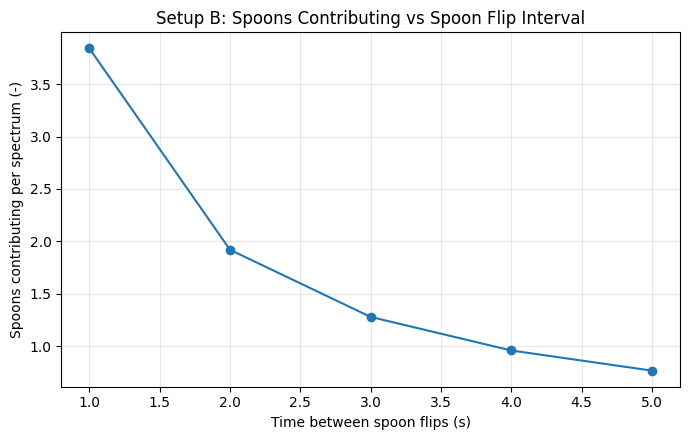

In [10]:
spoons_vs_interval_df = pd.DataFrame(
    {
        "spoon_interval_s": spoon_intervals_s,
        "spoons_contributing": [spoons_contributing_from_interval(acq_time_s, float(s)) for s in spoon_intervals_s],
    }
)

plt.figure(figsize=(7, 4.5))
plt.plot(
    spoons_vs_interval_df["spoon_interval_s"],
    spoons_vs_interval_df["spoons_contributing"],
    marker="o",
)
plt.xlabel("Time between spoon flips (s)")
plt.ylabel("Spoons contributing per spectrum (-)")
plt.title("Setup B: Spoons Contributing vs Spoon Flip Interval")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


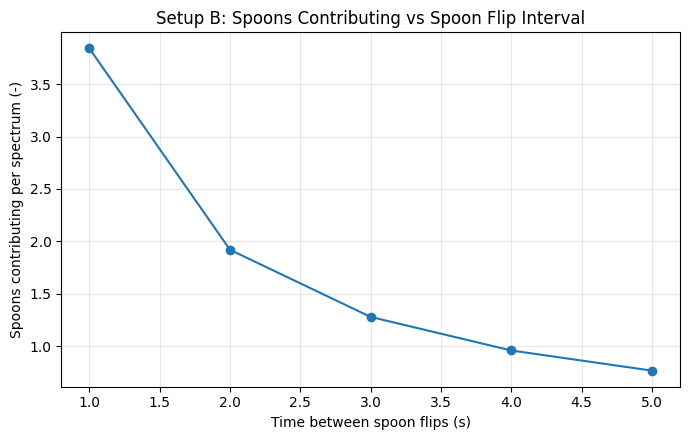

In [11]:
spoons_vs_interval_df = pd.DataFrame(
    {
        "spoon_interval_s": spoon_intervals_s,
        "spoons_contributing": [spoons_contributing_from_interval(acq_time_s, float(s)) for s in spoon_intervals_s],
    }
)

fig_setup_b_spoons_vs_interval, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(
    spoons_vs_interval_df["spoon_interval_s"],
    spoons_vs_interval_df["spoons_contributing"],
    marker="o",
)
ax.set_xlabel("Time between spoon flips (s)")
ax.set_ylabel("Spoons contributing per spectrum (-)")
ax.set_title("Setup B: Spoons Contributing vs Spoon Flip Interval")
ax.grid(True, alpha=0.3)
fig_setup_b_spoons_vs_interval.tight_layout()
plt.show()


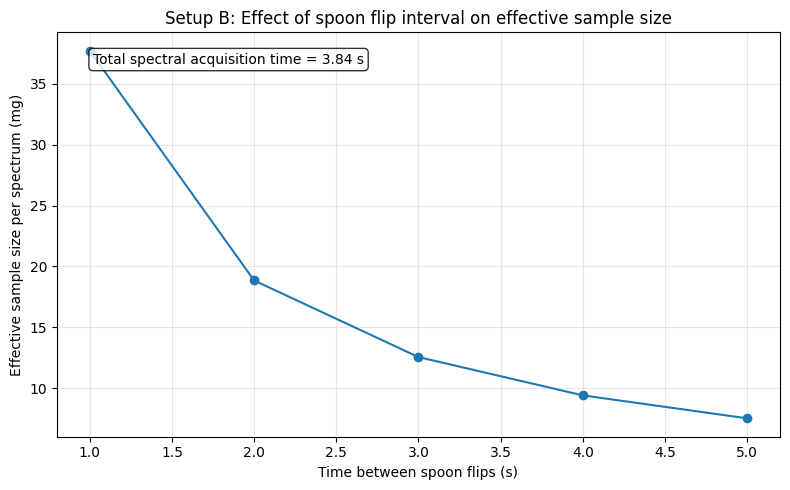

,bulk_density_g_per_cm3,spoon_interval_s,spoon_presentations,static_sample_mass_per_spoon_g,static_sample_mass_per_spoon_mg,spoon_sample_volume_cm3,representative_penetration_depth_mm,total_spectral_acquisition_time_s,effective_sample_size_g,effective_sample_size_mg
0,0.5,1.0,3.840,0.009817,9.817477,0.019635,1.0,3.84,0.037699,37.699112
1,0.5,2.0,1.920,0.009817,9.817477,0.019635,1.0,3.84,0.018850,18.849556
2,0.5,3.0,1.280,0.009817,9.817477,0.019635,1.0,3.84,0.012566,12.566371
3,0.5,4.0,0.960,0.009817,9.817477,0.019635,1.0,3.84,0.009425,9.424778
4,0.5,5.0,0.768,0.009817,9.817477,0.019635,1.0,3.84,0.007540,7.539822


In [12]:
representative_bulk_density_g_per_cm3 = 0.5
representative_penetration_depth_mm_plot4 = 1.0
representative_penetration_depth_cm_plot4 = representative_penetration_depth_mm_plot4 / 10.0
illuminated_area_cm2_plot4 = probe_area_m2 * 1e4
spoon_sample_volume_cm3_plot4 = illuminated_area_cm2_plot4 * representative_penetration_depth_cm_plot4

static_sample_mass_per_spoon_g = representative_bulk_density_g_per_cm3 * spoon_sample_volume_cm3_plot4

plot4_results = []
for spoon_interval_s in spoon_intervals_s:
    spoon_presentations = total_spectral_acquisition_time_s / spoon_interval_s
    effective_sample_size_g = static_sample_mass_per_spoon_g * spoon_presentations
    effective_sample_size_mg = effective_sample_size_g * 1000.0

    plot4_results.append(
        {
            "bulk_density_g_per_cm3": representative_bulk_density_g_per_cm3,
            "spoon_interval_s": float(spoon_interval_s),
            "spoon_presentations": spoon_presentations,
            "static_sample_mass_per_spoon_g": static_sample_mass_per_spoon_g,
            "static_sample_mass_per_spoon_mg": static_sample_mass_per_spoon_g * 1000.0,
            "spoon_sample_volume_cm3": spoon_sample_volume_cm3_plot4,
            "representative_penetration_depth_mm": representative_penetration_depth_mm_plot4,
            "total_spectral_acquisition_time_s": total_spectral_acquisition_time_s,
            "effective_sample_size_g": effective_sample_size_g,
            "effective_sample_size_mg": effective_sample_size_mg,
        }
    )

df_plot4 = pd.DataFrame(plot4_results)

plt.figure(figsize=(8, 5))
plt.plot(
    df_plot4["spoon_interval_s"],
    df_plot4["effective_sample_size_mg"],
    marker="o",
)
plt.xlabel("Time between spoon flips (s)")
plt.ylabel("Effective sample size per spectrum (mg)")
plt.title("Setup B: Effect of spoon flip interval on effective sample size")

text_str = f"Total spectral acquisition time = {total_spectral_acquisition_time_s:.2f} s"
plt.text(
    0.05,
    0.95,
    text_str,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df_plot4

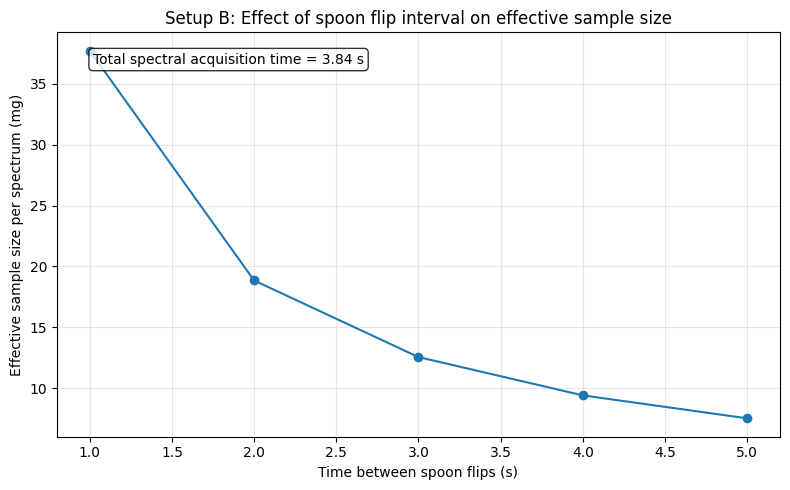

,bulk_density_g_per_cm3,spoon_interval_s,spoon_presentations,static_sample_mass_per_spoon_g,static_sample_mass_per_spoon_mg,spoon_sample_volume_cm3,representative_penetration_depth_mm,total_spectral_acquisition_time_s,effective_sample_size_g,effective_sample_size_mg
0,0.5,1.0,3.840,0.009817,9.817477,0.019635,1.0,3.84,0.037699,37.699112
1,0.5,2.0,1.920,0.009817,9.817477,0.019635,1.0,3.84,0.018850,18.849556
2,0.5,3.0,1.280,0.009817,9.817477,0.019635,1.0,3.84,0.012566,12.566371
3,0.5,4.0,0.960,0.009817,9.817477,0.019635,1.0,3.84,0.009425,9.424778
4,0.5,5.0,0.768,0.009817,9.817477,0.019635,1.0,3.84,0.007540,7.539822


In [13]:
representative_bulk_density_g_per_cm3 = 0.5
representative_penetration_depth_mm_plot4 = 1.0
representative_penetration_depth_cm_plot4 = representative_penetration_depth_mm_plot4 / 10.0
illuminated_area_cm2_plot4 = probe_area_m2 * 1e4
spoon_sample_volume_cm3_plot4 = illuminated_area_cm2_plot4 * representative_penetration_depth_cm_plot4

static_sample_mass_per_spoon_g = representative_bulk_density_g_per_cm3 * spoon_sample_volume_cm3_plot4

plot4_results = []
for spoon_interval_s in spoon_intervals_s:
    spoon_presentations = total_spectral_acquisition_time_s / spoon_interval_s
    effective_sample_size_g = static_sample_mass_per_spoon_g * spoon_presentations
    effective_sample_size_mg = effective_sample_size_g * 1000.0

    plot4_results.append(
        {
            "bulk_density_g_per_cm3": representative_bulk_density_g_per_cm3,
            "spoon_interval_s": float(spoon_interval_s),
            "spoon_presentations": spoon_presentations,
            "static_sample_mass_per_spoon_g": static_sample_mass_per_spoon_g,
            "static_sample_mass_per_spoon_mg": static_sample_mass_per_spoon_g * 1000.0,
            "spoon_sample_volume_cm3": spoon_sample_volume_cm3_plot4,
            "representative_penetration_depth_mm": representative_penetration_depth_mm_plot4,
            "total_spectral_acquisition_time_s": total_spectral_acquisition_time_s,
            "effective_sample_size_g": effective_sample_size_g,
            "effective_sample_size_mg": effective_sample_size_mg,
        }
    )

df_plot4 = pd.DataFrame(plot4_results)

fig_setup_b_interval_effect, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    df_plot4["spoon_interval_s"],
    df_plot4["effective_sample_size_mg"],
    marker="o",
)
ax.set_xlabel("Time between spoon flips (s)")
ax.set_ylabel("Effective sample size per spectrum (mg)")
ax.set_title("Setup B: Effect of spoon flip interval on effective sample size")

text_str = f"Total spectral acquisition time = {total_spectral_acquisition_time_s:.2f} s"
ax.text(
    0.05,
    0.95,
    text_str,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

ax.grid(True, alpha=0.3)
fig_setup_b_interval_effect.tight_layout()
plt.show()

df_plot4


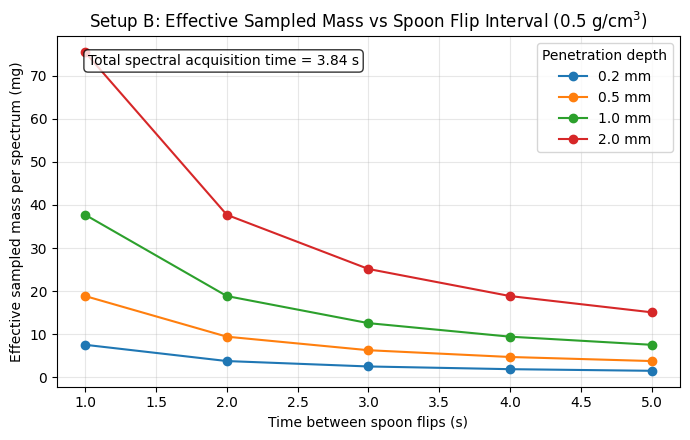

In [14]:
selected_depths_mm = [0.2, 0.5, 1.0, 2.0]
effective_mass_vs_interval_df = results_df[
    (results_df["bulk_density_g_cm3"] == representative_bulk_density_g_per_cm3)
    & (results_df["penetration_depth_mm"].isin(selected_depths_mm))
].copy()

plt.figure(figsize=(7, 4.5))
for penetration_depth_mm, group_df in effective_mass_vs_interval_df.groupby("penetration_depth_mm"):
    group_df = group_df.sort_values("spoon_interval_s")
    plt.plot(
        group_df["spoon_interval_s"],
        group_df["effective_sampled_mass_mg"],
        marker="o",
        label=f"{penetration_depth_mm:.1f} mm",
    )

plt.xlabel("Time between spoon flips (s)")
plt.ylabel("Effective sampled mass per spectrum (mg)")
plt.title("Setup B: Effective Sampled Mass vs Spoon Flip Interval (0.5 g/cm$^3$)")

text_str = f"Total spectral acquisition time = {total_spectral_acquisition_time_s:.2f} s"
plt.text(
    0.05,
    0.95,
    text_str,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.legend(title="Penetration depth")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results Interpretation

- Plot 2 shows static sample mass per spoon for three representative bulk densities: 0.4, 0.5, and 0.6 g/cm$^3$
- Plot 4 uses only representative bulk density 0.5 g/cm$^3$
- Plot 4 x-axis is time between spoon flips (s), not flip frequency (Hz)
- shorter spoon intervals produce more independent spoon presentations during acquisition, increasing effective sample size

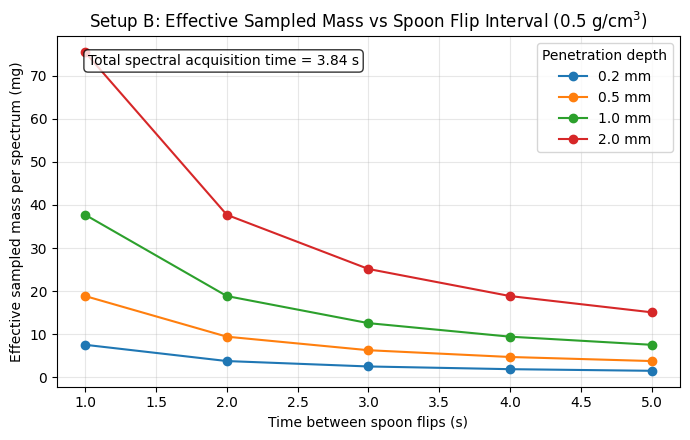

In [15]:
selected_depths_mm = [0.2, 0.5, 1.0, 2.0]
effective_mass_vs_interval_df = results_df[
    (results_df["bulk_density_g_cm3"] == representative_bulk_density_g_per_cm3)
    & (results_df["penetration_depth_mm"].isin(selected_depths_mm))
].copy()

fig_setup_b_selected_depths, ax = plt.subplots(figsize=(7, 4.5))
for penetration_depth_mm, group_df in effective_mass_vs_interval_df.groupby("penetration_depth_mm"):
    group_df = group_df.sort_values("spoon_interval_s")
    ax.plot(
        group_df["spoon_interval_s"],
        group_df["effective_sampled_mass_mg"],
        marker="o",
        label=f"{penetration_depth_mm:.1f} mm",
    )

ax.set_xlabel("Time between spoon flips (s)")
ax.set_ylabel("Effective sampled mass per spectrum (mg)")
ax.set_title("Setup B: Effective Sampled Mass vs Spoon Flip Interval (0.5 g/cm$^3$)")

text_str = f"Total spectral acquisition time = {total_spectral_acquisition_time_s:.2f} s"
ax.text(
    0.05,
    0.95,
    text_str,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
ax.legend(title="Penetration depth")
ax.grid(True, alpha=0.3)
fig_setup_b_selected_depths.tight_layout()
plt.show()


## Limitations

- independence between spoons is assumed
- complete and reproducible filling is assumed
- no explicit throughput effect is included
- no dynamic filling physics is modeled
- no partial spoon overlap model is included
- no integer/discrete spoon capture model is enforced
- no optical weighting correction yet

## Next logical extensions

- enforce integer spoon counting or partial spoon weighting
- include incomplete filling scenarios
- include non-independent spoons
- include spoon geometry explicitly
- include particle count estimation
- include uncertainty in penetration depth and bulk density

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [16]:

from pathlib import Path
import importlib
import sys

project_root = Path(r"C:\Users\Erik\Documents\Projects\EFS")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_word_report = reporting_utils.build_word_report
create_run_directory = reporting_utils.create_run_directory
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_b"
notebook_filename = "setup_B_spoon_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_b_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = grouped_summary_df.copy()
selected_depths_table_df = effective_mass_vs_interval_df.copy()

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "input_summary": input_summary_df,
    "flip_summary": flip_summary_df,
    "plot2_static_sample_mass_table": df_plot2,
    "plot4_spoon_interval_effect_table": df_plot4,
    "selected_depths_interval_table": selected_depths_table_df,
}
figures_to_save = {
    "plot_01_static_sampled_volume_per_spoon": globals().get("fig_setup_b_volume"),
    "plot_02_static_sample_mass_per_spoon": globals().get("fig_setup_b_static_sample_mass"),
    "plot_03_spoons_contributing_vs_interval": globals().get("fig_setup_b_spoons_vs_interval"),
    "plot_04_effective_sample_size_vs_flip_interval": globals().get("fig_setup_b_interval_effect"),
    "plot_05_effective_mass_vs_flip_interval_selected_depths": globals().get("fig_setup_b_selected_depths"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Probe diameter (mm)": probe_diameter_mm,
    "Penetration depth range (mm)": f"{penetration_depths_mm.min():.1f} to {penetration_depths_mm.max():.1f}",
    "Penetration depth step (mm)": 0.1,
    "Bulk densities (g/cm^3)": [float(x) for x in bulk_densities_g_cm3],
    "Subscans": int(n_subscans),
    "Integration time (ms)": integration_time_ms,
    "Acquisition time (s)": acquisition_time_s,
    "Spoon intervals (s)": [float(x) for x in spoon_intervals_s],
}
purpose_text = (
    "Setup B estimates effective sampled mass per spectrum by combining static optical mass per spoon with the "
    "deterministic number of spoon presentations during one spectral acquisition."
)
assumptions_text = (
    "Each spoon presentation is treated as an independent static optical event, spoon filling is reproducible, "
    "and effective sample size scales with flip frequency over the acquisition window."
)
metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

build_word_report(
    report_title="Setup B Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    purpose_text=purpose_text,
    assumptions_text=assumptions_text,
    parameter_summary=parameter_summary,
    csv_filenames=csv_files,
    figure_filenames=png_files,
    output_filename=report_filename,
)

print(f"Report run directory: {run_dir}")


Report run directory: C:\Users\Erik\Documents\Projects\EFS\reports\setup_b\20260315_214727
